# Task 01 — Feature engineering & cleaning

## 🌌 Macrocosm photo-z — outlier study (tasks 2026-06-16)

**✅ GIVEN (do NOT re-derive this):** we already ran a **400k 5-fold cross-validation** with three
models (HGB, RF, MLP) and collected the galaxies that *all three* predict catastrophically out-of-fold
(|Δz/(1+z)| > 0.05). There are **6,974** such **hard** galaxies. Their objids are in
**`../hard_objids.csv`**. Treat this hard set as a **fixed input** — your job is to characterize / act
on it, not to re-find it from 400k.

**Catalog:** `gs://macrocosm-lewagon/data/sample_v1/catalog_v1.parquet` (600k rows, 55 columns).
The SDSS **`-9999` sentinel** means "not measured" — always clean it to NaN first.

**Metric:** `σ_MAD = 1.4826 · median(|Δz − median(Δz)|)`, with `Δz = (z_pred − z_true)/(1+z)`;
an **outlier** is `|Δz| > 0.05`. σ_MAD is the headline metric, report **outlier rate** alongside it.

---

Build the modelling feature set from the raw catalog and sanity-check it. Everyone else builds on this
recipe, so get it right: clean the `-9999` sentinel, derive the 4 colors, log the right-skewed sizes.

In [9]:
# === shared setup: load catalog, clean -9999, build the 16 features ===
import pandas as pd, numpy as np

CATALOG = "/Users/appalonovaa/code/Macrocosm/catalog_v1.parquet"
# Colab: from google.colab import auth; auth.authenticate_user()
# or download once: !gcloud storage cp $CATALOG . , then CATALOG = "catalog_v1.parquet"

FEATS = ["dered_u","dered_g","dered_r","dered_i","dered_z","g-r","u-g","r-i","i-z",
         "log_expRad_r","log_deVRad_r","log_petroRad_r","log_petroR50_r","log_petroR90_r",
         "fracDeV_r","conc_r"]

def load_features(path=CATALOG, n=None, seed=0):
    """Load catalog, clean the -9999 sentinel, build colors / log-sizes / conc.
    Returns (D, cat): D = features+redshift+objid (optionally subsampled), cat = full cleaned catalog."""
    cat = pd.read_parquet(path)
    num = cat.select_dtypes("number").columns
    cat[num] = cat[num].mask(cat[num] <= -100)                       # clean SDSS -9999
    for a, b in [("u","g"),("g","r"),("r","i"),("i","z")]:
        cat[f"{a}-{b}"] = (cat[f"dered_{a}"] - cat[f"dered_{b}"]).clip(-1, 4)
    for s in ["expRad_r","deVRad_r","petroRad_r","petroR50_r","petroR90_r"]:
        cat["log_"+s] = np.log1p(cat[s].clip(lower=0))
    cat["conc_r"] = cat["petroR90_r"] / cat["petroR50_r"].replace(0, np.nan)
    D = cat[FEATS + ["redshift","objid"]].replace([np.inf,-np.inf], np.nan).dropna()
    if n:
        D = D.sample(n, random_state=seed).reset_index(drop=True)
    return D, cat

def smad(dz): return 1.4826 * np.median(np.abs(dz - np.median(dz)))

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    dz = (y_pred - y_true) / (1 + y_true)
    return {"MAE": round(float(np.mean(np.abs(y_pred-y_true))), 5),
            "sigma_MAD": round(float(smad(dz)), 5),
            "outlier_rate": round(float(np.mean(np.abs(dz) > 0.05)), 5)}

# the GIVEN hard set (6,974 objids from the 400k 5-fold CV)
HARD = set(pd.read_csv("../hard_objids.csv")["objid"])
print(f"hard set: {len(HARD)} galaxies")

hard set: 6974 galaxies


❓ **Question (load & clean)** ❓

👇 Load 100k rows with `load_features(n=100000, seed=0)`. Print `D.shape` and `FEATS`.

In [10]:
D, cat = load_features(n=100000, seed=0)

print(D.shape)
print(FEATS)

(100000, 18)
['dered_u', 'dered_g', 'dered_r', 'dered_i', 'dered_z', 'g-r', 'u-g', 'r-i', 'i-z', 'log_expRad_r', 'log_deVRad_r', 'log_petroRad_r', 'log_petroR50_r', 'log_petroR90_r', 'fracDeV_r', 'conc_r']


❓ **Question (distributions)** ❓

👇 Plot histograms of `dered_r`, `g-r` and `redshift`. After cleaning, are the magnitude/color ranges physical (no -9999 spikes)?

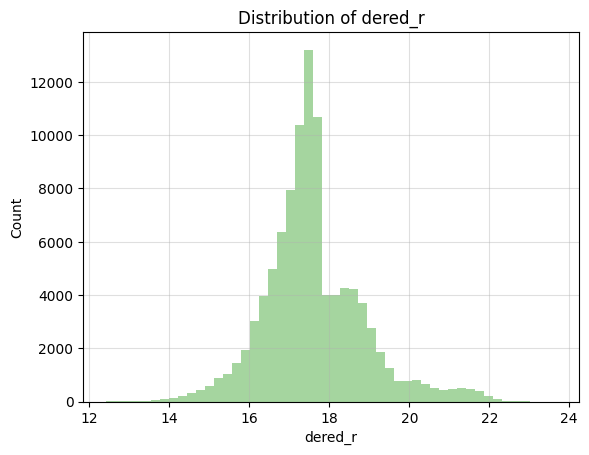

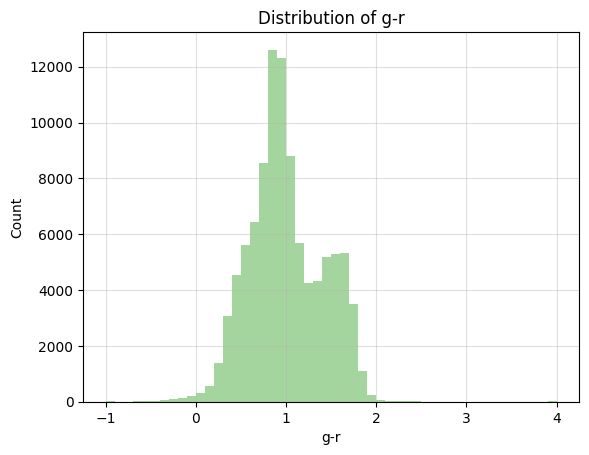

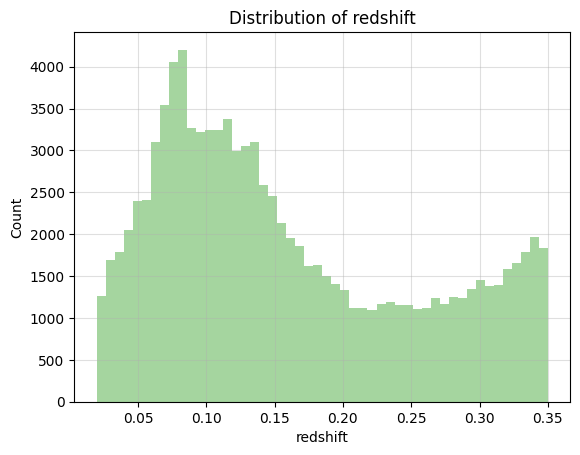

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

D["dered_r"].hist(bins=50, color='#7fc476', alpha=0.7)
plt.title("Distribution of dered_r")
plt.xlabel("dered_r")
plt.ylabel("Count")
plt.grid(alpha=0.4)
plt.show()

D["g-r"].hist(bins=50, color='#7fc476', alpha=0.7)
plt.title("Distribution of g-r")
plt.xlabel("g-r")
plt.ylabel("Count")
plt.grid(alpha=0.4)
plt.show()

D["redshift"].hist(bins=50, color='#7fc476', alpha=0.7)
plt.title("Distribution of redshift")
plt.xlabel("redshift")
plt.ylabel("Count")
plt.grid(alpha=0.4)
plt.show()

❓ **Question (signal)** ❓

👇 Which features correlate most with `redshift`? Compute `D[FEATS].corrwith(D['redshift'])` and sort by |corr|.

In [17]:
corr = D[FEATS].corrwith(D["redshift"])

corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

print(corr_sorted)

dered_u           0.814186
g-r               0.797339
dered_g           0.790704
dered_r           0.629687
dered_i           0.571295
r-i               0.571211
dered_z           0.523227
log_expRad_r     -0.515594
log_deVRad_r     -0.451032
u-g               0.422613
log_petroR50_r   -0.380031
log_petroRad_r   -0.321906
fracDeV_r         0.318841
log_petroR90_r   -0.293332
i-z               0.285750
conc_r            0.177814
dtype: float64


## 📝 Write your report

In [24]:
# === write_report: run this after you've filled in your results, it generates report.md ===
def write_report(title, results: dict, conclusion: str, path="report.md"):
    lines = [f"# {title}", "", "_Auto-generated by task.ipynb — fill `results` and `conclusion` above._", "",
             "## Results", ""]
    for k, v in results.items():
        lines.append(f"- **{k}**: {v}")
    lines += ["", "## Conclusion", "", conclusion, ""]
    with open(path, "w") as f:
        f.write("\n".join(lines))
    print("wrote", path)

In [25]:
write_report(
    "Task 01 — Feature engineering",
    {
        "n_features": len(FEATS),
        "top_corr_features": corr_sorted.head(5).to_dict(),
        "missing_after_clean": int(D[FEATS].isna().sum().sum())
    },
    (
        "The cleaned dataset contains 16 features with no missing values after cleaning. "
        "The most related features to redshift are dered_u, g-r, dered_g, dered_r and dered_i. "
        "The galaxy size features log_expRad_r, log_deVRad_r, log_petroR50_r, log_petroRad_r, and log_petroR90_r have a negative correlation with redshift. "
    )
)

wrote report.md


In [ ]:
# === Commit & push your results (run last; make sure you are on branch 2026.6.16) ===
# First time: git pull origin 2026.6.16   to get the latest.
!git add task.ipynb report.md && git commit -m "01-feature-engineering task" && git push origin 2026.6.16

## 🔭 Go further (optional)

Play around with the data and the results you now have. If you find anything new — an unexpected pattern, a useful feature, a failure mode we missed — write it up and post it to our **YouTrack Knowledge Base** so the whole team benefits.